In [1]:
import csv
import nibabel as nib
import matplotlib.pyplot as plt
import random
import torch
import os
import numpy as np
from model1 import CNN_3D,NiiDataset,MultiModalTransformer,NeuralNet,TransEModel,KGMultiModalTransformer
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import nibabel as nib
import shutil
import torch.nn as nn
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import math
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import pandas as pd

In [2]:
path_existence = []
data_prodromal=[]
data_swedd=[]
data_control=[]
data_PD = []
count_control = 0
count_PD = 0
count_swedd = 0
count_prodromal = 0
with open('PD1.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader)  
    for row in csv_reader:
        path = 'PD/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_PD=count_PD+1
            data_PD.append(row)
            
with open('control.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader) 
    for row in csv_reader:
        path = 'Control/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_control=count_control+1
            data_control.append(row)
            
with open('swedd.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader) 
    for row in csv_reader:
        path = 'SWEDD/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_swedd=count_swedd+1
            data_swedd.append(row)

with open('prodromal.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader) 
    for row in csv_reader:
        path = 'Prodromal/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_prodromal=count_prodromal+1
            data_prodromal.append(row)
print(count_PD) #125
print(count_control) #132
print(count_swedd) #72
print(count_prodromal)#80

125
132
72
80


In [3]:
PD_arrays=[]
replace_dict = {'F': '0','M':'1','Normal':'0','Slight':'1','Mild':'2','Moderate':'3','Severe':'4','T1-anatomical':'1','Processed':'1', 
               'BL':'0','V04':'1','V06':'2','V06':'3','V08':'4','V10':'5','NiFTI':'1','':'0','No':'0','Yes':'1','Stage 1':'1','Stage 2':'2','Stage 3':'3','Stage 4':'4'
               ,'On':'1','Off':'0','Stage 0':'0'}
for i in data_PD:
    j= i[21:]
    j= [replace_dict.get(item, item) for item in j]
    num_list = [float(num) for num in j]
    PD_array = np.array(num_list)
    PD_arrays.append(PD_array)
PD_array = np.vstack(PD_arrays)

control_arrays = []
for i in data_control:
    j = i[21:]
    j = [replace_dict.get(item, item) for item in j]
    num_list = [float(num) for num in j]
    control_array = np.array(num_list)
    control_arrays.append(control_array)
control_array = np.vstack(control_arrays)

swedd_arrays = []
for i in data_swedd:
    j = i[21:]
    j = [replace_dict.get(item, item) for item in j]
    num_list = [float(num) for num in j]
    swedd_array = np.array(num_list)
    swedd_arrays.append(swedd_array)
swedd_array = np.vstack(swedd_arrays)

prodromal_arrays = []
for i in data_prodromal:
    j = i[21:]
    j = [replace_dict.get(item, item) for item in j]
    num_list = [float(num) for num in j]
    prodromal_array = np.array(num_list)
    prodromal_arrays.append(prodromal_array)
prodromal_array = np.vstack(prodromal_arrays)

#加权算值
def weighted_sum(tensor):
    weights = [0.1, 0.3, 0.5 , 0.7]
    weight_tensor = torch.tensor(weights, dtype=tensor.dtype, device=tensor.device)
    weighted_sum_result = torch.sum(tensor * weight_tensor, dim=1, keepdim=True)
    return weighted_sum_result

In [4]:
pd_tensor = torch.from_numpy(PD_array).float()
control_tensor = torch.from_numpy(control_array).float()
swedd_tensor = torch.from_numpy(swedd_array).float()
prodromal_tensor = torch.from_numpy(prodromal_array).float()

pd_labels = torch.zeros(pd_tensor.shape[0], dtype=torch.long)
control_labels = torch.ones(control_tensor.shape[0], dtype=torch.long)
swedd_labels = torch.full((swedd_tensor.shape[0],), 3, dtype=torch.long)
prodromal_labels = torch.full((prodromal_tensor.shape[0],), 2, dtype=torch.long)

X = torch.cat([pd_tensor, control_tensor, swedd_tensor,prodromal_tensor], dim=0)
y = torch.cat([pd_labels , control_labels  ,swedd_labels, prodromal_labels], dim=0)

dataset = TensorDataset(X, y)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)
model = NeuralNet(embedding=64)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
num_epochs = 50
for epoch in range(num_epochs):
    for inputs, labels in dataloader:
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')
        
with torch.no_grad():
    pd_tensor = model(pd_tensor)
    control_tensor = model(control_tensor)
    swedd_tensor = model(swedd_tensor)
    prodromal_tensor = model(prodromal_tensor)
    
pd_tensor = weighted_sum(pd_tensor)
control_tensor = weighted_sum(control_tensor)
swedd_tensor = weighted_sum(swedd_tensor)
prodromal_tensor = weighted_sum(prodromal_tensor)

Epoch [10/50], Loss: 0.8978
Epoch [20/50], Loss: 0.8462
Epoch [30/50], Loss: 0.5109
Epoch [40/50], Loss: 0.3175
Epoch [50/50], Loss: 0.3783


In [5]:
# 数据处理函数
def preprocess_data(data, replace_dict):
    processed_data = []
    for row in data:
        row = [replace_dict.get(item, item) for item in row]
        row = [float(item) if item.replace('.', '', 1).isdigit() else item for item in row]
        processed_data.append(row[4:22])
    return np.array(processed_data)
# 编码类别型变量
def encode_categorical(data, categorical_indices):
    encoded_data = data.copy()
    for idx in categorical_indices:
        le = LabelEncoder()
        encoded_data[:, idx] = le.fit_transform(encoded_data[:, idx])
    return encoded_data.astype(float)

In [6]:
pd_data = preprocess_data(data_PD, replace_dict)
control_data = preprocess_data(data_control, replace_dict)
swedd_data = preprocess_data(data_swedd, replace_dict)
prodromal_data = preprocess_data(data_prodromal, replace_dict)

categorical_indices = [2, 3, 4, 5]  # gender, education, hispanic, race, apoe
pd_EHR = encode_categorical(pd_data, categorical_indices)
control_EHR = encode_categorical(control_data, categorical_indices)
swedd_EHR = encode_categorical(swedd_data, categorical_indices)
prodromal_EHR = encode_categorical(prodromal_data, categorical_indices)

pd_EHR = torch.from_numpy(pd_EHR).float()
control_EHR = torch.from_numpy(control_EHR).float()
swedd_EHR = torch.from_numpy(swedd_EHR).float()
prodromal_EHR = torch.from_numpy(prodromal_EHR).float()

linear_layer = nn.Linear(18, 16)
control_EHR = linear_layer(control_EHR)
pd_EHR = linear_layer(pd_EHR)
swedd_EHR = linear_layer(swedd_EHR)
prodromal_EHR = linear_layer(prodromal_EHR)

linear_layer = nn.Linear(16, 1)
control_EHR = linear_layer(control_EHR)
pd_EHR = linear_layer(pd_EHR)
swedd_EHR = linear_layer(swedd_EHR)
prodromal_EHR = linear_layer(prodromal_EHR)

print('pd.EHR--->', pd_EHR.shape)
print('control.EHR--->', control_EHR.shape)
print('swedd.EHR--->', swedd_EHR.shape)
print('prodromal.EHR--->', prodromal_EHR.shape)

pd.EHR---> torch.Size([125, 1])
control.EHR---> torch.Size([132, 1])
swedd.EHR---> torch.Size([72, 1])
prodromal.EHR---> torch.Size([80, 1])


In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [8]:
def center_crop_3d(tensor, size):
    depth, height, width = tensor.shape
    target_depth, target_height, target_width = size

    start_depth = (depth - target_depth) // 2
    start_height = (height - target_height) // 2
    start_width = (width - target_width) // 2

    end_depth = start_depth + target_depth
    end_height = start_height + target_height
    end_width = start_width + target_width

    return tensor[start_depth:end_depth, start_height:end_height, start_width:end_width]

In [9]:
import os
import torch
from torch.utils.data import DataLoader, Dataset
import nibabel as nib

# 你的 NiiDataset，务必用这版
class NiiDataset(Dataset):
    def __init__(self, file_list_or_folder):
        if isinstance(file_list_or_folder, list):
            self.file_list = file_list_or_folder
        elif isinstance(file_list_or_folder, str):
            folder_path = file_list_or_folder
            self.file_list = [os.path.join(folder_path, filename)
                              for filename in os.listdir(folder_path)
                              if filename.endswith('.nii') or filename.endswith('.nii.gz')]
        else:
            raise ValueError("参数应为list或str")
    def __len__(self):
        return len(self.file_list)
    def __getitem__(self, idx):
        file_path = self.file_list[idx]
        img = nib.load(file_path)
        img_data = img.get_fdata()
        img_tensor = torch.from_numpy(img_data).float()
        cropped_tensor = center_crop_3d(img_tensor, (64, 64, 64))   # 你的裁剪函数
        input_tensor = cropped_tensor.unsqueeze(0)
        return input_tensor

# 1. 严格用csv顺序生成影像路径
pd_img_paths = [os.path.join('PD', row[1]) for row in data_PD if os.path.exists(os.path.join('PD', row[1]))]
control_img_paths = [os.path.join('Control', row[1]) for row in data_control if os.path.exists(os.path.join('Control', row[1]))]
swedd_img_paths = [os.path.join('SWEDD', row[1]) for row in data_swedd if os.path.exists(os.path.join('SWEDD', row[1]))]
prodromal_img_paths = [os.path.join('Prodromal', row[1]) for row in data_prodromal if os.path.exists(os.path.join('Prodromal', row[1]))]

print(f'PD影像数量: {len(pd_img_paths)}')
print(f'Control影像数量: {len(control_img_paths)}')
print(f'SWEDD影像数量: {len(swedd_img_paths)}')
print(f'Prodromal影像数量: {len(prodromal_img_paths)}')

batch_size = 16
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
nii = CNN_3D(num_class=1)
nii = nii.to(device)

# 2. 用于影像特征提取
# PD组
dataset = NiiDataset(pd_img_paths)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
all_outputs = []
for batch_idx, batch_data in enumerate(dataloader):
    batch_data = batch_data.to(device)
    output = nii(batch_data)
    all_outputs.append(output)
PD_output = torch.cat(all_outputs, dim=0)
print('PD nii shape--->', PD_output.shape)

# Control组
dataset = NiiDataset(control_img_paths)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
all_outputs = []
for batch_idx, batch_data in enumerate(dataloader):
    batch_data = batch_data.to(device)
    output = nii(batch_data)
    all_outputs.append(output)
control_output = torch.cat(all_outputs, dim=0)
print('control nii shape--->', control_output.shape)

# Prodromal组
dataset = NiiDataset(prodromal_img_paths)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
all_outputs = []
for batch_idx, batch_data in enumerate(dataloader):
    batch_data = batch_data.to(device)
    output = nii(batch_data)
    all_outputs.append(output)
prodromal_output = torch.cat(all_outputs, dim=0)
print('prodromal nii shape--->', prodromal_output.shape)

# SWEDD组
dataset = NiiDataset(swedd_img_paths)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
all_outputs = []
for batch_idx, batch_data in enumerate(dataloader):
    batch_data = batch_data.to(device)
    output = nii(batch_data)
    all_outputs.append(output)
swedd_output = torch.cat(all_outputs, dim=0)
print('swedd nii shape--->', swedd_output.shape)

PD影像数量: 125
Control影像数量: 132
SWEDD影像数量: 72
Prodromal影像数量: 80
PD nii shape---> torch.Size([125, 1])
control nii shape---> torch.Size([132, 1])
prodromal nii shape---> torch.Size([80, 1])
swedd nii shape---> torch.Size([72, 1])


In [10]:
# ===== 读取 DistMult 实体向量 =====
pd_df        = pd.read_csv('PD1.csv')
control_df   = pd.read_csv('control.csv')
prodromal_df = pd.read_csv('prodromal.csv')
swedd_df     = pd.read_csv('swedd.csv')

# 路径与文件名（根据你的脚本输出）
ENTITY_EMB_NPY = "entity_embeddings_distmult_PD.npy"
ENTITY2ID_TXT  = "entity2id_distmult_PD.txt"

# 1) 读实体→id 映射
entity2id = {}
with open(ENTITY2ID_TXT, "r", encoding="utf-8") as f:
    for line in f:
        ent, idx = line.strip().split("\t")
        entity2id[ent] = idx  # 注意 idx 是 str，后面会再映射到行号

# 2) 加载实体嵌入矩阵 (shape = [n_ent, 32])
entity_embeddings = torch.from_numpy(np.load(ENTITY_EMB_NPY)).float()

# 3) 把 id → 行号 做成 dict，方便索引
id_to_index = {id_str: idx for idx, id_str in enumerate(sorted(entity2id.values(), key=int))}

# 4) DistMultExtract：与之前 TransEextract 逻辑一致，只是名字改一下
class DistMultExtract:
    def __init__(self, entity_embeddings, entity2id, id_to_index):
        self.entity_embeddings = entity_embeddings
        self.entity2id = entity2id
        self.id_to_index = id_to_index

    def get_entity_embedding(self, entity):
        if entity in self.entity2id:
            ent_id = self.entity2id[entity]
            row_idx = self.id_to_index[ent_id]
            return self.entity_embeddings[row_idx]
        else:
            raise KeyError(f"Entity {entity} not found in entity2id mapping")

# 5) 初始化提取器
kg_extractor = DistMultExtract(entity_embeddings, entity2id, id_to_index)

# 6) 原先 get_embeddings() 函数保持不变，只把调用处的 `model=` 参数
#    换成新提取器 'kg_extractor'
def get_embeddings(df, extractor, nii_folder):
    embeddings_list = []
    skipped_rows = 0
    for _, row in df.iterrows():
        nii_file = row.iloc[1]
        nii_path = os.path.join(nii_folder, nii_file)
        if not os.path.exists(nii_path):
            skipped_rows += 1
            continue
        row_embeddings = []
        for col in df.columns[7:]:
            entity = str(row[col])
            if entity != '0' and entity in extractor.entity2id:
                row_embeddings.append(extractor.get_entity_embedding(entity))
        filename = str(row['Subject'])
        if filename in extractor.entity2id:
            row_embeddings.append(extractor.get_entity_embedding(filename))
        if row_embeddings:
            mean_embedding = torch.stack(row_embeddings).mean(dim=0)
            embeddings_list.append(mean_embedding)
    if not embeddings_list:
        return torch.empty((0, 32))
    return torch.stack(embeddings_list)

# 7) 获取四个 cohort 的 DistMult 嵌入
pd_transe        = get_embeddings(pd_df,        kg_extractor, 'PD')
control_transe   = get_embeddings(control_df,   kg_extractor, 'Control')
prodromal_transe = get_embeddings(prodromal_df, kg_extractor, 'Prodromal')
swedd_transe     = get_embeddings(swedd_df,     kg_extractor, 'SWEDD')

print(pd_transe.shape, control_transe.shape, prodromal_transe.shape, swedd_transe.shape)



torch.Size([125, 32]) torch.Size([132, 32]) torch.Size([80, 32]) torch.Size([72, 32])


In [11]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    all_probs = []
    all_labels = []
    all_preds = []
    
    for inputs, transe_embed, labels in loader:
        inputs, transe_embed, labels = inputs.to(device), transe_embed.to(device), labels.to(device)
        labels = labels.long()
        
        optimizer.zero_grad()
        outputs = model(inputs, transe_embed)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()

        probs = torch.softmax(outputs, dim=1).detach().cpu().numpy()
        preds = torch.argmax(outputs, dim=1).detach().cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds)

    # Convert lists to numpy arrays for easier manipulation
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)

    train_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')
    train_f1 = f1_score(all_labels, all_preds, average='macro')
    train_recall = recall_score(all_labels, all_preds, average='macro')
    train_precision = precision_score(all_labels, all_preds, average='macro')

    avg_loss = total_loss / len(loader)
    return avg_loss, train_auc, train_f1, train_recall, train_precision

def validate_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_probs = []
    all_labels = []
    all_preds = []
    with torch.no_grad():
        for inputs, transe_embed, labels in loader:
            inputs, transe_embed, labels = inputs.to(device), transe_embed.to(device), labels.to(device)
            labels = labels.long()
            
            outputs = model(inputs, transe_embed)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            probs = torch.softmax(outputs, dim=1).detach().cpu().numpy()
            preds = torch.argmax(outputs, dim=1).detach().cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds)
    
    
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)

    # 计算指标
    val_auc = roc_auc_score(all_labels, all_probs, multi_class='ovo')
    val_f1 = f1_score(all_labels, all_preds, average='macro')
    val_recall = recall_score(all_labels, all_preds, average='macro')
    val_precision = precision_score(all_labels, all_preds, average='macro')
    
    # 计算平均损失
    avg_loss = total_loss / len(loader)
    return avg_loss, val_auc, val_f1, val_recall, val_precision


In [12]:
# ------- 重新拼接特征 + 构造 DataLoader ------- #
transe_embed_dim = 32   # DistMult 嵌入维度

X_pd = torch.cat([pd_EHR, PD_output.cpu(), pd_tensor, pd_transe], dim=1)
X_control = torch.cat([control_EHR, control_output.cpu(), control_tensor, control_transe], dim=1)
X_swedd = torch.cat([swedd_EHR, swedd_output.cpu(), swedd_tensor, swedd_transe], dim=1)
X_prodromal = torch.cat([prodromal_EHR, prodromal_output.cpu(), prodromal_tensor, prodromal_transe], dim=1)

y_pd = torch.zeros(len(X_pd))          # 标签顺序 PD=0
y_control = torch.ones(len(X_control)) # Control=1
y_swedd = torch.full((len(X_swedd),), 2)
y_prodromal = torch.full((len(X_prodromal),), 3)

X = torch.cat([X_pd[:120], X_control, X_prodromal, X_swedd], dim=0).float()
y = torch.cat([y_pd[:120], y_control, y_prodromal, y_swedd], dim=0).float()

features = X[:, :-transe_embed_dim]
kg_embed = X[:, -transe_embed_dim:]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test, kg_train, kg_test = train_test_split(
    features.detach().cpu().numpy(),          # ←★ 改这里
    y.cpu().numpy(),
    kg_embed.detach().cpu().numpy(),          # ←★ 以及这里
    test_size=0.20, stratify=y.cpu().numpy(), random_state=32
)

X_train, X_val, y_train, y_val, kg_train, kg_val = train_test_split(
    X_train, y_train, kg_train,
    test_size=0.20, stratify=y_train, random_state=30
)




In [13]:
# === cell12a: 消融实验开关（PPMI 四分类） ===
# 选项: "none"（不消融）, "no_ehr", "no_mri", "no_kg"
ABLATION = "no_mri"

# 切分后是否用训练集均值替代被消融列（更严谨，避免置零带来分布偏移）
FILL_WITH_TRAIN_MEAN = True

# 保持你旧实验里 “PD 只取前 120 个样本” 的设定；如不需要可设为 None
KEEP_PD_N = 120



In [14]:
# === cell12（替换原 cell12）: 构建三列非KG + KG，应用消融，切分并重建 DataLoader ===
import torch
import numpy as np
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader

BUILD_DEVICE = torch.device("cpu")  # 构建阶段统一在 CPU，后面 DataLoader 再送 GPU

def _to2d_cpu_float(x):
    if isinstance(x, np.ndarray): x = torch.from_numpy(x)
    elif not isinstance(x, torch.Tensor): x = torch.tensor(x)
    if x.ndim == 1: x = x.view(-1, 1)
    return x.detach().to(BUILD_DEVICE).float()

def _to2d_cpu_float_no_force_1d(x):
    if isinstance(x, np.ndarray): x = torch.from_numpy(x)
    elif not isinstance(x, torch.Tensor): x = torch.tensor(x)
    if x.ndim == 1: x = x.view(-1, 1)
    return x.detach().to(BUILD_DEVICE).float()

def _to1d_cpu_long(y):
    if isinstance(y, np.ndarray): y = torch.from_numpy(y)
    elif not isinstance(y, torch.Tensor): y = torch.tensor(y)
    return y.view(-1).to(BUILD_DEVICE).long()

def _pack_one_class(ehr1, mri1, ehr2, kg, label_id, keep_n=None, name=""):
    """将单一类别的三列非KG与KG对齐，必要时截断到相同长度；返回 (X_3col, KG, y)"""
    E1  = _to2d_cpu_float(ehr1)
    M1  = _to2d_cpu_float(mri1)
    E2  = _to2d_cpu_float(ehr2)
    KG  = _to2d_cpu_float_no_force_1d(kg)
    n   = min(E1.shape[0], M1.shape[0], E2.shape[0], KG.shape[0])
    if keep_n is not None:
        n = min(n, int(keep_n))
    E1, M1, E2, KG = E1[:n], M1[:n], E2[:n], KG[:n]
    X3 = torch.cat([E1, M1, E2], dim=1)  # 列序固定: [EHR(1), MRI(1), EHR(2)]
    y  = torch.full((n,), int(label_id), dtype=torch.long)
    print(f"[{name}] packed -> X:{X3.shape} KG:{KG.shape} y:{y.shape}")
    return X3, KG, y

# —— 用你现有的四类变量名组装（严格按你代码里的命名）——
# EHR 单列: pd_EHR / control_EHR / swedd_EHR / prodromal_EHR
# MRI 单列: PD_output / control_output / swedd_output / prodromal_output
# EHR(2)单列: pd_tensor / control_tensor / swedd_tensor / prodromal_tensor
# KG 32维: pd_transe / control_transe / swedd_transe / prodromal_transe
# 标签映射按你原 cell12：PD=0, Control=1, SWEDD=2, Prodromal=3
X_pd,        KG_pd,        y_pd        = _pack_one_class(pd_EHR,        PD_output,        pd_tensor,        pd_transe,        0, keep_n=KEEP_PD_N, name="PD")
X_control,   KG_control,   y_control   = _pack_one_class(control_EHR,   control_output,   control_tensor,   control_transe,   1, keep_n=None,      name="Control")
X_swedd,     KG_swedd,     y_swedd     = _pack_one_class(swedd_EHR,     swedd_output,     swedd_tensor,     swedd_transe,     2, keep_n=None,      name="SWEDD")
X_prodromal, KG_prodromal, y_prodromal = _pack_one_class(prodromal_EHR, prodromal_output, prodromal_tensor, prodromal_transe, 3, keep_n=None,      name="Prodromal")

# —— 应用消融掩码（保持形状不变）——
fill = 0.0
if ABLATION == "no_ehr":
    for M in (X_pd, X_control, X_swedd, X_prodromal):
        M[:, [0, 2]] = fill
elif ABLATION == "no_mri":
    for M in (X_pd, X_control, X_swedd, X_prodromal):
        M[:, [1]] = fill
elif ABLATION == "no_kg":
    KG_pd        = torch.zeros_like(KG_pd)
    KG_control   = torch.zeros_like(KG_control)
    KG_swedd     = torch.zeros_like(KG_swedd)
    KG_prodromal = torch.zeros_like(KG_prodromal)

# —— 汇总为全样本 ——（按 PD→Control→SWEDD→Prodromal 的顺序，与你标签一致）
features_all = torch.cat([X_pd, X_control, X_swedd, X_prodromal], dim=0).float()   # [N, 3]
kg_all       = torch.cat([KG_pd, KG_control, KG_swedd, KG_prodromal], dim=0).float()  # [N, 32]
y_all        = torch.cat([y_pd, y_control, y_swedd, y_prodromal], dim=0).long()    # [N]

print(f"[Ablation={ABLATION}] features:{features_all.shape} KG:{kg_all.shape} y:{y_all.shape}")
assert features_all.shape[1] == 3,  f"features 应为 [N,3]，现在是 {features_all.shape}"
assert kg_all.ndim == 2 and kg_all.shape[1] == 32, f"KG 应为 [N,32]，现在是 {kg_all.shape}"

# —— 切分（与你原 cell12 的比例/随机种子对齐）——
X_train, X_test, y_train, y_test, kg_train, kg_test = train_test_split(
    features_all, y_all, kg_all, test_size=0.20, stratify=y_all, random_state=32
)
X_train, X_val, y_train, y_val, kg_train, kg_val = train_test_split(
    X_train, y_train, kg_train, test_size=0.20, stratify=y_train, random_state=30
)

# —— 可选：用“训练集均值”替代被消融列（更严谨）——
if FILL_WITH_TRAIN_MEAN and ABLATION in ("no_ehr", "no_mri"):
    cols = [0, 2] if ABLATION == "no_ehr" else [1]
    with torch.no_grad():
        mu = X_train[:, cols].mean(dim=0, keepdim=True)
        for M in (X_train, X_val, X_test):
            M[:, cols] = mu

# —— 重建 DataLoader（与 train_epoch/validate_epoch 的三元组对齐）——
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 清掉旧的 loader，防误用
for name in ["train_loader", "val_loader", "test_loader"]:
    if name in globals(): globals()[name] = None

X_train_tensor = X_train.to(torch.float32).to(device)
y_train_tensor = y_train.to(torch.long).to(device)
kg_train_tensor = kg_train.to(torch.float32).to(device)

X_val_tensor = X_val.to(torch.float32).to(device)
y_val_tensor = y_val.to(torch.long).to(device)
kg_val_tensor = kg_val.to(torch.float32).to(device)

X_test_tensor = X_test.to(torch.float32).to(device)
y_test_tensor = y_test.to(torch.long).to(device)
kg_test_tensor = kg_test.to(torch.float32).to(device)

batch_size = 32
train_dataset = TensorDataset(X_train_tensor, kg_train_tensor, y_train_tensor)
val_dataset   = TensorDataset(X_val_tensor,   kg_val_tensor,  y_val_tensor)
test_dataset  = TensorDataset(X_test_tensor,  kg_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  drop_last=False)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, drop_last=False)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, drop_last=False)

# Sanity：确认被掩码列真的“无信息”
cols = [0, 2] if ABLATION == "no_ehr" else ([1] if ABLATION == "no_mri" else [])
if cols:
    with torch.no_grad():
        std_train = X_train_tensor[:, cols].std(dim=0).detach().cpu().tolist()
        std_val   = X_val_tensor[:,   cols].std(dim=0).detach().cpu().tolist()
        std_test  = X_test_tensor[:,  cols].std(dim=0).detach().cpu().tolist()
    print(f"[sanity] masked cols {cols} std -> train:{std_train}  val:{std_val}  test:{std_test}")
else:
    print("[sanity] no masked cols (ABLATION='none' 或 'no_kg').")

print("DataLoaders ready:", len(train_loader), len(val_loader), len(test_loader))


[PD] packed -> X:torch.Size([120, 3]) KG:torch.Size([120, 32]) y:torch.Size([120])
[Control] packed -> X:torch.Size([132, 3]) KG:torch.Size([132, 32]) y:torch.Size([132])
[SWEDD] packed -> X:torch.Size([72, 3]) KG:torch.Size([72, 32]) y:torch.Size([72])
[Prodromal] packed -> X:torch.Size([80, 3]) KG:torch.Size([80, 32]) y:torch.Size([80])
[Ablation=no_mri] features:torch.Size([404, 3]) KG:torch.Size([404, 32]) y:torch.Size([404])
[sanity] masked cols [1] std -> train:[0.0]  val:[0.0]  test:[0.0]
DataLoaders ready: 9 3 3


In [15]:
embed_dim        = 32
transe_embed_dim = 32          # 名字不改省事；实际装的是 DistMult
num_epochs       = 200
batch_size       = 32
learning_rate    = 1e-5
weight_decay     = 1e-3
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# KGMultiModalTransformer 保持不变，只是继续把 transe_embed_dim=32 传进去
model = KGMultiModalTransformer(embed_dim=embed_dim,
                                transe_embed_dim=transe_embed_dim).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

train_losses = []
train_aucs = []
train_f1s = []
train_recalls = []
train_precisions = []
test_losses = []
test_aucs = []
test_f1s = []
test_recalls = []
test_precisions = []

for epoch in range(num_epochs):
    train_loss, train_auc, train_f1, train_recall, train_precision = train_epoch(model, train_loader, optimizer, criterion, device)
    test_loss, test_auc, test_f1, test_recall, test_precision = validate_epoch(model, test_loader, criterion, device)
    
    train_losses.append(train_loss)
    train_aucs.append(train_auc)
    train_f1s.append(train_f1)
    train_recalls.append(train_recall)
    train_precisions.append(train_precision)
    
    test_losses.append(test_loss)
    test_aucs.append(test_auc)
    test_f1s.append(test_f1)
    test_recalls.append(test_recall)
    test_precisions.append(test_precision)
    
    print(f"Epoch {epoch + 1}/{num_epochs}, "
          f"Train Loss: {train_loss:.4f}, Train AUC: {train_auc:.4f}  "   
          f"test Loss: {test_loss:.4f}, test AUC: {test_auc:.4f}")

/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoch 1/200, Train Loss: 1.3401, Train AUC: 0.6497  test Loss: 1.3721, test AUC: 0.6241
Epoch 2/200, Train Loss: 1.3301, Train AUC: 0.6712  test Loss: 1.3692, test AUC: 0.6278


/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoch 3/200, Train Loss: 1.3315, Train AUC: 0.6857  test Loss: 1.3635, test AUC: 0.6568
Epoch 4/200, Train Loss: 1.3349, Train AUC: 0.6833  test Loss: 1.3543, test AUC: 0.7004
Epoch 5/200, Train Loss: 1.3086, Train AUC: 0.7151  test Loss: 1.3389, test AUC: 0.7275
Epoch 6/200, Train Loss: 1.3231, Train AUC: 0.7047  test Loss: 1.3150, test AUC: 0.7361
Epoch 7/200, Train Loss: 1.2644, Train AUC: 0.7383  test Loss: 1.2937, test AUC: 0.7457
Epoch 8/200, Train Loss: 1.2641, Train AUC: 0.7046  test Loss: 1.2741, test AUC: 0.7657


/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


...

Epoch 191/200, Train Loss: 0.7862, Train AUC: 0.9152  test Loss: 0.7517, test AUC: 0.9006
Epoch 192/200, Train Loss: 0.7261, Train AUC: 0.9092  test Loss: 0.7589, test AUC: 0.8998
Epoch 193/200, Train Loss: 0.7342, Train AUC: 0.9088  test Loss: 0.7494, test AUC: 0.9035
Epoch 194/200, Train Loss: 0.7247, Train AUC: 0.9133  test Loss: 0.7519, test AUC: 0.9035


/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoch 195/200, Train Loss: 0.7221, Train AUC: 0.9038  test Loss: 0.7761, test AUC: 0.9027
Epoch 196/200, Train Loss: 0.7871, Train AUC: 0.9070  test Loss: 0.7728, test AUC: 0.8990
Epoch 197/200, Train Loss: 0.8267, Train AUC: 0.9021  test Loss: 0.7547, test AUC: 0.9040
Epoch 198/200, Train Loss: 0.7447, Train AUC: 0.9061  test Loss: 0.7724, test AUC: 0.9026


/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoch 199/200, Train Loss: 0.7906, Train AUC: 0.9046  test Loss: 0.7574, test AUC: 0.9036
Epoch 200/200, Train Loss: 0.8554, Train AUC: 0.9051  test Loss: 0.7557, test AUC: 0.9017


In [16]:
model.eval()
all_probs = []
all_labels = []
with torch.no_grad():
    for inputs, transe_embed, labels in val_loader:
        inputs, transe_embed, labels = inputs.to(device), transe_embed.to(device), labels.to(device)
        outputs = model(inputs, transe_embed)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy())

preds = np.argmax(all_probs, axis=1)
accuracy = accuracy_score(all_labels, preds)
precision = precision_score(all_labels, preds, average='macro')
recall = recall_score(all_labels, preds, average='macro')
f1 = f1_score(all_labels, preds, average='macro')
auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')

print("\n=== Final Validation Metrics ===")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"AUC-ROC:   {auc:.4f}")


=== Final Validation Metrics ===
Accuracy:  0.6923
Precision: 0.5378
Recall:    0.6565
F1 Score:  0.5868
AUC-ROC:   0.9011


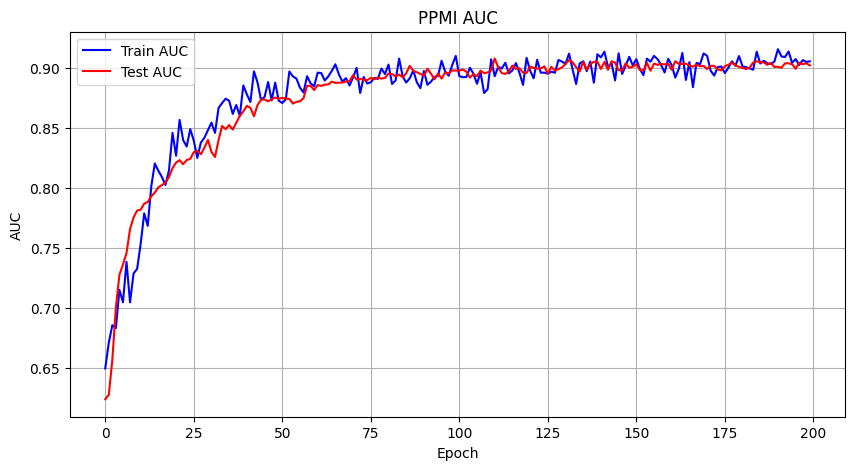

In [17]:
plt.figure(figsize=(10, 5))
plt.plot(range(len(train_aucs)), train_aucs, label="Train AUC", color="blue")
plt.plot(range(len(test_aucs)), test_aucs, label="Test AUC", color="red")
plt.title("PPMI AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend()
plt.grid(True)
plt.show()

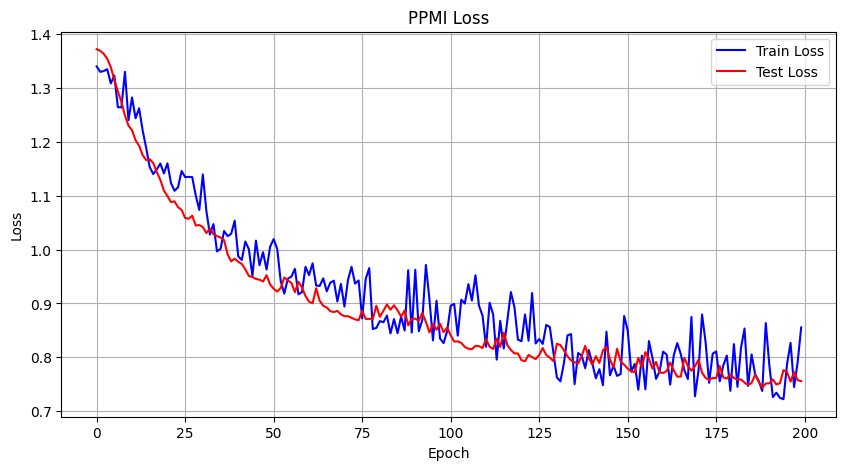

In [18]:
plt.figure(figsize=(10, 5))
plt.plot(range(len(train_losses)), train_losses, label="Train Loss", color="blue")
plt.plot(range(len(test_losses)), test_losses, label="Test Loss", color="red")
plt.title("PPMI Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [19]:
# ===== 计算并绘制测试集混淆矩阵 =====
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

model.eval()
all_preds   = []
all_labels  = []

with torch.no_grad():
    for inputs, kg_embed, labels in test_loader:
        inputs, kg_embed = inputs.to(device), kg_embed.to(device)
        outputs = model(inputs, kg_embed)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

# 1. 数值矩阵
cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix (counts):\n", cm)

# 2. 文字报告（可选）
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=["PD", "Control", "SWEDD", "Prodromal"]))

# 3. 热力图可视化
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True, fmt="d", cmap="Blues",
    xticklabels=["PD", "Control", "SWEDD", "Prodromal"],
    yticklabels=["PD", "Control", "SWEDD", "Prodromal"]
)
plt.title("Confusion Matrix – Test Set")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


ModuleNotFoundError: No module named 'seaborn'

In [ ]:
# === 模型算力 & 显存开销评估 ===
import time
import math
import torch

def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def _run_one_pass(model, batch, device, is_train=False, criterion=None):
    """
    兼容两种 DataLoader 输出：
    1. (inputs, labels)           —— 双模态 / 三模态无 k
    2. (inputs, kg_embed, labels) —— 三模态 + KG/DistMult/TransE
    """
    if isinstance(batch, (list, tuple)):
        if len(batch) == 2:
            x, y = batch
            x, y = x.to(device), y.to(device)
            inputs = (x,)
            labels = y.long()
        elif len(batch) == 3:
            x1, x2, y = batch
            x1, x2, y = x1.to(device), x2.to(device), y.to(device)
            inputs = (x1, x2)
            labels = y.long()
        else:
            raise ValueError(f"Unexpected batch structure, len={len(batch)}")
    else:
        raise ValueError(f"Unexpected batch type: {type(batch)}")

    if is_train:
        # 优先用你上面定义好的 criterion，没有就临时建一个
        if criterion is None:
            criterion_local = torch.nn.CrossEntropyLoss()
        else:
            criterion_local = criterion
    else:
        criterion_local = None

    start = time.perf_counter()
    if len(inputs) == 1:
        outputs = model(inputs[0])
    else:
        outputs = model(*inputs)

    if is_train and criterion_local is not None:
        loss = criterion_local(outputs, labels)
        # 不做 optimizer.step，只做 backward，模拟训练算力消耗
        model.zero_grad()
        loss.backward()

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    end = time.perf_counter()
    return end - start, labels.size(0)

def benchmark(model, loader, device, mode="inference", max_batches=10, criterion=None):
    """
    mode = "inference" 或 "train"
    max_batches 控制最多用多少个 batch 做采样，避免跑太久
    """
    use_cuda = torch.cuda.is_available()
    if use_cuda:
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats(device)

    model.to(device)
    is_train = (mode == "train")
    if is_train:
        model.train()
    else:
        model.eval()

    times = []
    total_samples = 0

    with torch.set_grad_enabled(is_train):
        for b_idx, batch in enumerate(loader):
            if b_idx >= max_batches:
                break
            t, n = _run_one_pass(model, batch, device,
                                 is_train=is_train, criterion=criterion)
            times.append(t)
            total_samples += n

    if not times:
        raise RuntimeError("benchmark loader is empty.")

    avg = sum(times) / len(times)
    var = sum((t - avg) ** 2 for t in times) / len(times)
    std = math.sqrt(var)
    batch_size = loader.batch_size if hasattr(loader, "batch_size") else int(round(total_samples / len(times)))
    peak_mem_mb = None
    if use_cuda:
        peak_mem_mb = torch.cuda.max_memory_allocated(device) / (1024 ** 2)

    return {
        "mode": mode,
        "batch_size": batch_size,
        "num_batches": len(times),
        "num_samples": total_samples,
        "avg_time_s_per_batch": avg,
        "std_time_s_per_batch": std,
        "avg_time_ms_per_sample": avg * 1000.0 * batch_size,
        "peak_mem_mb": peak_mem_mb,
    }

def run_full_profile(model, train_loader, test_loader, device, criterion=None, epochs_for_est=200):
    # 1. 参数量（大致权重内存）
    n_params = count_trainable_params(model)
    print(f"Model parameters: {n_params:,} (~{n_params * 4 / 1024 / 1024:.2f} MB FP32)")

    # 2. 推理阶段算力 & 显存
    print("\n=== Inference Microbenchmark ===")
    inf_stats = benchmark(
        model, test_loader, device,
        mode="inference", max_batches=10, criterion=None
    )
    for k, v in inf_stats.items():
        print(f"{k:>25}: {v}")

    # 3. 训练阶段算力（forward+backward，不更新参数） & 显存
    print("\n=== Training Microbenchmark (forward + backward, no optimizer.step) ===")
    train_stats = benchmark(
        model, train_loader, device,
        mode="train", max_batches=10, criterion=criterion
    )
    for k, v in train_stats.items():
        print(f"{k:>25}: {v}")

    # 4. 估算多 epoch 训练时间
    steps_per_epoch = len(train_loader)
    est_time_epoch = train_stats["avg_time_s_per_batch"] * steps_per_epoch
    print(f"\n=== 训练{epochs_for_est}轮算力评估 ===")
    print(f"训练批次数/轮: {steps_per_epoch}")
    print(f"估计单轮训练时间: {est_time_epoch:.3f}s (~{est_time_epoch/3600:.4f} h)")
    print(f"估计{epochs_for_est}轮训练时间: {est_time_epoch*epochs_for_est:.1f}s (~{est_time_epoch*epochs_for_est/3600:.4f} h)")

    # 5. 显存开销
    if inf_stats["peak_mem_mb"] is not None:
        print(f"\n推理阶段峰值显存占用: {inf_stats['peak_mem_mb']:.2f} MB")
        print(f"训练阶段峰值显存占用: {train_stats['peak_mem_mb']:.2f} MB")
    else:
        print("\n当前为 CPU 模式，无法统计 GPU 显存开销。")

# 直接调用一次，默认估计 200 epoch 的训练时间
# 注意：请确保上面已经执行过：
# - device = torch.device(...)
# - train_loader / test_loader / model / criterion 都已创建
run_full_profile(model, train_loader, test_loader, device, criterion, epochs_for_est=200)
